In [1]:
# ─── Environment Setup (do not edit) ────────────────────────────────────────
import os, sys
from pathlib import Path


# ── 1. Detect platform ──
def _detect_platform():
    # Colab
    try:
        import google.colab  # noqa: F401

        return "colab", False
    except ImportError:
        pass
    # Vast.ai (confident: env var present)
    if Path("/workspace").exists() and os.environ.get("VAST_CONTAINERLABEL"):
        return "vastai", False
    # Vast.ai (weak signal: /workspace exists but no env var)
    if Path("/workspace").exists():
        return "vastai", True  # True = uncertain, emit warning
    # Windows
    if sys.platform == "win32":
        return "windows", False
    # Mac
    if sys.platform == "darwin":
        return "mac", False
    # Unknown
    return None, True


PLATFORM, _uncertain = _detect_platform()

# ── 2. Mount Drive (Colab only) ──
if PLATFORM == "colab":
    from google.colab import drive

    drive.mount("/content/drive")

# ── 3. Resolve project root ──
try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
else:
    # notebooks/pipelines/ → go up 2 levels to project root
    PROJECT_ROOT = _nb_path.parents[1]

sys.path.insert(0, str(PROJECT_ROOT))

# ── 4. Select .env file ──
_env_map = {
    "colab": PROJECT_ROOT / ".env.colab",
    "vastai": PROJECT_ROOT / ".env.vastai",
    "windows": PROJECT_ROOT / ".env.windows",
    "mac": PROJECT_ROOT / ".env.mac",
}

if PLATFORM is None:
    print("⚠️  WARNING: Could not detect platform. Falling back to .env (local).")
    print("   To silence this, set PLATFORM explicitly in your .env file.")
    _env_file = PROJECT_ROOT / ".env"
elif _uncertain:
    print(f"⚠️  WARNING: Detected /workspace but VAST_CONTAINERLABEL is not set.")
    print(
        f"   Assuming Vast.ai. To confirm, add VAST_CONTAINERLABEL to your .env.vastai."
    )
    _env_file = _env_map["vastai"]
else:
    _env_file = _env_map[PLATFORM]

# ── 5. Load .env ──
from dotenv import load_dotenv

if not _env_file.exists():
    _fallback = PROJECT_ROOT / ".env"
    print(f"⚠️  WARNING: Expected env file not found: {_env_file}")
    if _fallback.exists():
        print(f"   Falling back to: {_fallback}")
        _env_file = _fallback
    else:
        raise FileNotFoundError(
            f"No .env file found. Copy the correct example file:\n"
            f"  cp .env.{PLATFORM or 'mac'}.example .env.{PLATFORM or 'mac'}\n"
            f"Available: .env.vastai.example | .env.colab.example | .env.mac.example | .env.windows.example"
        )

load_dotenv(_env_file, override=True)

# ── 6. Resolve DATA_ROOT ──
from src.utils.env_utils import get_data_root

DATA_ROOT = get_data_root()

print(f"✅ Platform : {PLATFORM or 'unknown (local fallback)'}")
print(f"✅ Env file : {_env_file}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print(f"{'✅' if DATA_ROOT.exists() else '❌'} Path exists: {DATA_ROOT.exists()}")
if not DATA_ROOT.exists():
    print("   DATA_ROOT does not exist. Check your .env path or sync data first.")

✅ Platform : mac
✅ Env file : /Users/haila/My File/projects/fake-new-detection/.env.mac
✅ DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
✅ Path exists: True


# MM-ViFactCheck Integration — Stage 2 (Frozen COOLANT + Gated Fusion)

**Pipeline notebook 4/4** — Loads the frozen ResNetCOOLANT Stage 1 checkpoint from Phase 3, pre-extracts
per-pair `text_aligned_clip` + `image_aligned_clip` features into a cached HDF5 joined with ViFactCheck
ground-truth labels, trains four ablation configurations (A–D) of a `GatedFusionHead` classifier, evaluates
each on the test split, and exports an ablation table, confusion matrix, and JSON results for thesis
documentation.

---

**Inputs:**

-   `Input: training/checkpoints_coolant/<run_name>/best_model.pth (Phase 3 Stage 1 frozen checkpoint)`
-   `Input: processed_data/hdf5/coolant_{train,dev,test}.h5 (Phase 2 features)`
-   `Input: notebooks/data/json/news_data_vifactcheck_{train,dev,test}_labeled.json (ViFactCheck labels)`

**Outputs:**

-   `Output: training/stage2_features/stage2_{train,dev,test}.h5 (cached per-pair COOLANT outputs + labels)`
-   `Output: training/checkpoints_stage2/{config}_<timestamp>/best_model.pth`
-   `Output: training/stage2_results/{ablation_table.csv, test_confusion_matrix.png, mm_vifactcheck_results.json}`

---

### Architecture Note: MMVF-02 Resolution

The original MMVF-02 requirement described a separate Stage 2 PhoBERT `[Statement; SEP; Evidence]` encoder
producing a `[CLS]` vector (768-dim) that would flow into the fusion head alongside COOLANT image features.
**This requirement has been superseded by the locked architecture (D-03):** the PhoBERT-base-v2 token
features from Phase 2 already flow through COOLANT's text projector (`clip_module.text_projection`) into
`text_aligned_clip` (128-dim), eliminating the need for a redundant second PhoBERT forward pass.
Both modalities entering the fusion head are thus 128-dim outputs of the frozen Stage 1 COOLANT model.
This is cleaner architecturally and produces a stronger thesis ablation story.
See `docs/COOLANT_WORKFLOW_ANALYSIS.md` for the full COOLANT paper vs. implementation discrepancy analysis.


## Step 1: Configuration

All tunable parameters in one cell. Adjust paths and hyperparameters here before running the notebook.


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "pipeline" else Path.cwd()

try:
    from dotenv import load_dotenv

    load_dotenv(PROJECT_ROOT / ".env", override=False)
except ImportError:
    pass

# DATA_ROOT: where large files live (hdf5, checkpoints, mlruns).
# Defaults to DATA_ROOT env var, or PROJECT_ROOT if unset.
DATA_ROOT = (
    Path(os.environ["DATA_ROOT"]) if os.environ.get("DATA_ROOT") else PROJECT_ROOT
)

CONFIG = {
    "paths": {
        "project_root": PROJECT_ROOT,
        "hdf5_dir": DATA_ROOT / "processed_data" / "hdf5",
        "train_hdf5": DATA_ROOT / "processed_data" / "hdf5" / "coolant_train.h5",
        "dev_hdf5": DATA_ROOT / "processed_data" / "hdf5" / "coolant_dev.h5",
        "test_hdf5": DATA_ROOT / "processed_data" / "hdf5" / "coolant_test.h5",
        "labeled_json_dir": DATA_ROOT / "data" / "json",
        "stage1_checkpoint_root": DATA_ROOT / "training" / "checkpoints_coolant",
        "stage1_manifest": None,  # auto-detect newest checkpoint_manifest.json
        "stage2_features_dir": DATA_ROOT / "training" / "stage2_features",
        "stage2_checkpoint_root": DATA_ROOT / "training" / "checkpoints_stage2",
        "stage2_results_dir": DATA_ROOT / "training" / "stage2_results",
        # ── Stage 3.9 integration (Ablation E) ──────────────────────────────
        # Points to Stage 3.9 PhoBERT per-article features (768-dim CLS vectors).
        # Auto-detected from newest checkpoint_manifest.json under stage39_checkpoint_root.
        # Set stage39_manifest to a specific path to pin a run, or leave None for auto-detect.
        "stage39_checkpoint_root": DATA_ROOT / "training" / "checkpoints_vifactcheck",
        "stage39_manifest": None,
        "stage39_features_dir": DATA_ROOT / "training" / "stage39_features",
        "mlflow_dir": DATA_ROOT / "mlruns",
    },
    "data": {
        "source": "huggingface",  # "huggingface" | "json"
        "hf_dataset": "tranthaihoa/vifactcheck",
        "label_strategy": "three_class",  # matches 03.9_vifactcheck_training.ipynb
    },
    "model": {
        "text_dim": 64,  # COOLANT text_aligned_clip dim (Ablations A-D)
        "image_dim": 64,  # COOLANT image_aligned_clip dim
        "phobert_text_dim": 768,  # Stage 3.9 PhoBERT CLS dim (Ablation E)
        "fusion_hidden_dim": 256,
        "num_classes": 3,
        "dropout": 0.3,
    },
    "training": {
        "batch_size": 32,
        "max_epochs": 30,
        "patience": 7,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "label_smoothing": 0.1,
        "grad_clip": 1.0,
        "onecycle_pct_start": 0.05,
        # Ablations A-D use COOLANT features (text_dim=64, image_dim=64)
        # Ablation E uses Stage 3.9 PhoBERT text (phobert_text_dim=768) + COOLANT image (64)
        "ablation_configs": [
            "text_only",
            "image_only",
            "concat",
            "gated",
            "phobert_gated",
        ],
    },
    "mlflow": {
        "experiment_name": "mm-vifactcheck-stage2",
    },
    "safety": {
        "smoke_test": False,
        "smoke_batches": 2,
        "smoke_epochs": 5,
        "auto_install_deps": False,
        "force_rebuild_features": True,  # Force rebuild to use HF labels
        "seed": 42,
    },
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_ROOT}")
print(f"Stage1 checkpoint root: {CONFIG['paths']['stage1_checkpoint_root']}")
print(f"Stage39 checkpoint root: {CONFIG['paths']['stage39_checkpoint_root']}")
print(f"Stage39 features dir:   {CONFIG['paths']['stage39_features_dir']}")
print(f"Stage2 results dir: {CONFIG['paths']['stage2_results_dir']}")
print(f"Data source: {CONFIG['data']['source']}")
print(f"Force rebuild features: {CONFIG['safety']['force_rebuild_features']}")

Project root: /Users/haila/My File/projects/fake-new-detection
Data root:    /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
Stage1 checkpoint root: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant
Stage39 checkpoint root: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_vifactcheck
Stage39 features dir:   /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage39_features
Stage2 results dir: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_results
Data source: huggingface
Force rebuild features: True


## Step 1: Dependency Preflight

Checks that all required packages are available before any computation begins.


In [3]:
import importlib

_required = [
    ("torch", "torch"),
    ("h5py", "h5py"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("tqdm", "tqdm"),
    ("sklearn", "scikit-learn"),
    ("mlflow", "mlflow"),
]

_missing = []
for mod, pkg in _required:
    if importlib.util.find_spec(mod) is None:
        _missing.append(pkg)

if _missing and not CONFIG["safety"]["auto_install_deps"]:
    _pkgs = " ".join(_missing)
    print(f"Missing packages: {_missing}")
    print(f"Install with pip:")
    print(f"  pip install mlflow seaborn scikit-learn tqdm h5py")
    print(f"Install with conda:")
    print(
        f"  conda install -n fake_news mlflow seaborn scikit-learn tqdm h5py -c conda-forge"
    )
    raise RuntimeError(
        f"Missing packages: {_missing}. Set AUTO_INSTALL_DEPS=True or install manually."
    )
elif _missing and CONFIG["safety"]["auto_install_deps"]:
    import subprocess, sys

    subprocess.check_call([sys.executable, "-m", "pip", "install"] + _missing)
else:
    print("All dependencies present.")

All dependencies present.


## Step 2: Device, Seed, and Project Setup

Selects compute device (`cuda > mps > cpu`), seeds all RNGs for reproducibility, creates output directories,
and adds the project `src/` package to the Python path.


In [4]:
import sys
import random
import json
import os
import numpy as np
import torch
import torch.nn as nn
from datetime import datetime
from pathlib import Path

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG["paths"]["stage2_features_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["paths"]["stage2_checkpoint_root"].mkdir(parents=True, exist_ok=True)
CONFIG["paths"]["stage2_results_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["paths"]["mlflow_dir"].mkdir(parents=True, exist_ok=True)


def select_device():
    from src.utils.device import get_device

    return get_device()


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"Seed set to {seed}")


device = select_device()
seed_everything(CONFIG["safety"]["seed"])
print(f"Device: {device}")

Seed set to 42
Device: mps


In [5]:
from src.models.resnet_coolant import ResNetCOOLANT
from src.preprocessing.coolant.pair_dataset import CoolantPairDataset
from src.utils.device import get_device

print("src imports OK")

src imports OK


## Step 3: Load Frozen COOLANT Stage 1 Checkpoint

Loads the Phase 3 `best_model.pth` via `checkpoint_manifest.json` (auto-detected from the newest run under
`training/checkpoints_coolant/`). Applies the full 6-patch chain to reconstruct the exact architecture used
during Stage 1 training, loads the state dict, then freezes all parameters — COOLANT acts as a pure feature
extractor throughout Phase 4 (D-02, MMVF-01).


In [6]:
def resolve_stage1_checkpoint(config):
    manifest_path = config["paths"]["stage1_manifest"]
    if manifest_path is not None and Path(manifest_path).exists():
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        return Path(manifest["best_checkpoint_path"])

    search_root = config["paths"]["stage1_checkpoint_root"]
    candidates = list(search_root.rglob("checkpoint_manifest.json"))
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint_manifest.json found under {search_root}. "
            f"Run Phase 3 first: notebooks/pipeline/03_coolant_training.ipynb"
        )
    newest_manifest = max(candidates, key=lambda p: p.stat().st_mtime)
    with open(newest_manifest, "r") as f:
        manifest = json.load(f)
    ckpt_path = Path(manifest["best_checkpoint_path"])
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Checkpoint {ckpt_path} listed in manifest does not exist. "
            f"Run Phase 3 first: notebooks/pipeline/03_coolant_training.ipynb"
        )
    return ckpt_path


def load_frozen_coolant(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)

    assert (
        ckpt.get("freeze_for_stage2") is True
    ), "Phase 3 checkpoint missing freeze_for_stage2 flag — re-train Stage 1"

    model = ResNetCOOLANT.from_config(ckpt["config"]["model"], device=str(device))
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    return model, ckpt


stage1_checkpoint_path = resolve_stage1_checkpoint(CONFIG)
stage1_model, stage1_ckpt = load_frozen_coolant(stage1_checkpoint_path, device)

total_params = sum(p.numel() for p in stage1_model.parameters())
trainable_params = sum(p.numel() for p in stage1_model.parameters() if p.requires_grad)
stage1_epoch = stage1_ckpt.get("epoch", "unknown")
stage1_val_acc = stage1_ckpt.get("metrics", {}).get("val_accuracy", "?")

print(f"Stage 1 checkpoint: {stage1_checkpoint_path}")
print(f"Stage 1 epoch: {stage1_epoch} | val_accuracy: {stage1_val_acc}")
print(
    f"Parameters — total: {total_params:,} | trainable: {trainable_params} (must be 0)"
)
assert trainable_params == 0, "COOLANT must be fully frozen for Stage 2"

Stage 1 checkpoint: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/best_model.pth
Stage 1 epoch: 18 | val_accuracy: 0.8695
Parameters — total: 5,610,288 | trainable: 0 (must be 0)


In [7]:
from torch.utils.data import DataLoader as _DL

STAGE1_OUTPUT_MODE = None

_probe_ds = CoolantPairDataset(str(CONFIG["paths"]["train_hdf5"]))
_probe_loader = _DL(_probe_ds, batch_size=2, shuffle=False, num_workers=0)
_probe_batch = next(iter(_probe_loader))
_caption, _image, _art_ids = _probe_batch
_caption = _caption.to(device)
_image = _image.to(device)

with torch.no_grad():
    _out = stage1_model(_caption, _image)

if isinstance(_out, dict):
    STAGE1_OUTPUT_MODE = "dict"
    _tac = _out["text_aligned_clip"]
    _iac = _out["image_aligned_clip"]
elif hasattr(_out, "text_aligned_clip"):
    STAGE1_OUTPUT_MODE = "attrs"
    _tac = _out.text_aligned_clip
    _iac = _out.image_aligned_clip
else:
    STAGE1_OUTPUT_MODE = "tuple"
    _tac = _out[0]
    _iac = _out[1]

print(f"STAGE1_OUTPUT_MODE: {STAGE1_OUTPUT_MODE}")
print(
    f"text_aligned_clip shape: {_tac.shape}  (expected [2, {CONFIG['model']['text_dim']}])"
)
print(
    f"image_aligned_clip shape: {_iac.shape}  (expected [2, {CONFIG['model']['image_dim']}])"
)
assert _tac.shape == (
    2,
    CONFIG["model"]["text_dim"],
), f"Unexpected text_aligned_clip shape: {_tac.shape}"
assert _iac.shape == (
    2,
    CONFIG["model"]["image_dim"],
), f"Unexpected image_aligned_clip shape: {_iac.shape}"

CoolantPairDataset: 6724 pairs from coolant_train.h5
STAGE1_OUTPUT_MODE: dict
text_aligned_clip shape: torch.Size([2, 64])  (expected [2, 64])
image_aligned_clip shape: torch.Size([2, 64])  (expected [2, 64])


## Step 4: Pre-extract COOLANT Features and Join ViFactCheck Labels

Runs the frozen Stage 1 COOLANT over each split's Phase 2 HDF5 once, collecting `text_aligned_clip` (128-dim)
and `image_aligned_clip` (128-dim) per article, then joins root ViFactCheck labels from
`news_data_vifactcheck_{split}_labeled.json` via `article_id`. Results are cached in
`training/stage2_features/stage2_{split}.h5` — subsequent runs skip extraction unless
`FORCE_REBUILD_FEATURES=True` (D-04, D-05, D-06, D-31).


In [8]:
import h5py
from tqdm.auto import tqdm


# Label mapping for ViFactCheck string labels → integers (used for JSON fallback)
LABEL_MAP = {
    "Non": 0,
    "real": 0,
    "REAL": 0,
    "0": 0,
    "Misinformation": 1,
    "misinformation": 1,
    "fake": 1,
    "FAKE": 1,
    "1": 1,
    "NEI": 2,
    "nei": 2,
    "2": 2,
}


def _apply_label_strategy(raw_label, strategy):
    """Apply label strategy to a raw integer label (mirrors 03.9_vifactcheck_training.ipynb)."""
    if raw_label is None:
        return None
    raw_label = int(raw_label)
    if strategy == "three_class":
        return raw_label if raw_label in (0, 1, 2) else None
    elif strategy == "nei_as_real":
        if raw_label == 1:
            return 1
        elif raw_label in (0, 2):
            return 0
        return None
    elif strategy == "binary_exclude_nei":
        if raw_label == 0:
            return 0
        elif raw_label == 1:
            return 1
        return None
    raise ValueError(f"Unknown strategy: {strategy}")


def _normalize_label(raw_label):
    """Convert string or other label formats to integer."""
    if raw_label is None:
        return None
    if isinstance(raw_label, (int, float)):
        return int(raw_label)
    if isinstance(raw_label, str):
        if raw_label in LABEL_MAP:
            return LABEL_MAP[raw_label]
        lower = raw_label.lower()
        if lower in LABEL_MAP:
            return LABEL_MAP[lower]
        try:
            return int(float(raw_label))
        except ValueError:
            pass
    raise ValueError(f"Unknown label format: {raw_label!r}. Add mapping to LABEL_MAP.")


def load_labels_from_hf(split, config):
    """Load ViFactCheck labels from HuggingFace, returning a list indexed by HF row index.

    Mirrors the label loading logic in 03.9_vifactcheck_training.ipynb so that
    article_ids in the Phase 2 HDF5 (which correspond to HF row indices) map correctly.
    """
    from datasets import load_dataset

    strategy = config["data"]["label_strategy"]
    hf_name = config["data"]["hf_dataset"]
    # HF dataset has 'train', 'test', 'dev' splits (not 'validation')
    hf_split = split  # Use split directly: train, dev, test

    hf_ds = load_dataset(hf_name, split=hf_split)

    articles = []
    skipped = 0
    label_counts = {}
    for row in hf_ds:
        # HF dataset uses 'labels' (plural), not 'label'
        raw = row.get("labels", row.get("label", row.get("verdict", None)))
        lbl = _apply_label_strategy(raw, strategy)
        articles.append({"label": lbl})
        if lbl is None:
            skipped += 1
        else:
            label_counts[lbl] = label_counts.get(lbl, 0) + 1

    print(f"[HF] {split}: {len(articles)} articles | skipped {skipped}")
    print(f"  Label distribution: {dict(sorted(label_counts.items()))}")
    return articles


def load_labeled_articles_from_json(labeled_json_path, config):
    """Load labels from local JSON, preserving index alignment (nulls kept in place as None)."""
    strategy = config["data"]["label_strategy"]
    with open(labeled_json_path, "r", encoding="utf-8") as f:
        articles = json.load(f)

    label_counts = {}
    skipped = 0
    for art in articles:
        raw_label = art.get("label")
        norm_label = _normalize_label(raw_label)
        if norm_label is not None:
            norm_label = _apply_label_strategy(norm_label, strategy)
        art["label"] = norm_label
        if norm_label is None:
            skipped += 1
        else:
            label_counts[norm_label] = label_counts.get(norm_label, 0) + 1

    valid = len(articles) - skipped
    print(f"[JSON] {labeled_json_path.name}: {valid} labeled | skipped {skipped}")
    print(f"  Label distribution: {dict(sorted(label_counts.items()))}")
    return articles, valid


def load_article_labels(split, labeled_json_path, config):
    """Load labels from HF (primary) or JSON (fallback). Returns (articles_list, source_str)."""
    source = config["data"]["source"]
    if source == "huggingface":
        try:
            return load_labels_from_hf(split, config), "huggingface"
        except Exception as e:
            print(f"⚠  HF load failed ({e}), falling back to JSON.")

    articles, valid = load_labeled_articles_from_json(labeled_json_path, config)
    if valid == 0:
        raise ValueError(
            f"No valid labeled articles in {labeled_json_path}. "
            f"Set data.source='huggingface' or populate the JSON with real labels."
        )
    return articles, "json"


def validate_phase2_hdf5(hdf5_path, split_name):
    if not Path(hdf5_path).exists():
        raise FileNotFoundError(
            f"Phase 2 HDF5 not found: {hdf5_path}. "
            f"Run Phase 2 preprocessing first: notebooks/pipeline/02_preprocessing.ipynb"
        )
    with h5py.File(hdf5_path, "r") as f:
        missing = [
            k
            for k in ["caption_features", "image_features", "article_ids"]
            if k not in f
        ]
        if missing:
            raise FileNotFoundError(
                f"Phase 2 HDF5 {hdf5_path} missing datasets {missing}. "
                f"Run Phase 2 preprocessing first: notebooks/pipeline/02_preprocessing.ipynb"
            )
    print(f"Phase 2 HDF5 [{split_name}] OK: {hdf5_path}")


def _extract_stage1_outputs(out):
    if STAGE1_OUTPUT_MODE == "dict":
        return out["text_aligned_clip"], out["image_aligned_clip"]
    elif STAGE1_OUTPUT_MODE == "attrs":
        return out.text_aligned_clip, out.image_aligned_clip
    else:
        return out[0], out[1]


def extract_and_cache_stage2_features(
    split_name, hdf5_path, labeled_json_path, model, config, device, output_path
):
    if Path(output_path).exists() and not config["safety"]["force_rebuild_features"]:
        print(f"[stage2 cache] {split_name}: using existing {output_path}")
        return

    articles_labeled, label_source = load_article_labels(
        split_name, labeled_json_path, config
    )
    validate_phase2_hdf5(hdf5_path, split_name)

    ds = CoolantPairDataset(str(hdf5_path))
    loader = torch.utils.data.DataLoader(
        ds, batch_size=config["training"]["batch_size"], shuffle=False, num_workers=0
    )

    all_art_ids = ds.article_ids
    # Convert string article_ids to integers if needed
    if all_art_ids.dtype.kind in ("S", "U"):  # String or Unicode dtype
        all_art_ids = np.array(
            [
                int(aid.decode() if isinstance(aid, bytes) else aid)
                for aid in all_art_ids
            ]
        )
    max_art_id = int(np.max(all_art_ids))
    if max_art_id >= len(articles_labeled):
        raise ValueError(
            f"article_id out of range — Phase 2 HDF5 and label source are not aligned. "
            f"max article_id={max_art_id} but label source has {len(articles_labeled)} entries."
        )

    text_feats_list, image_feats_list, labels_list, aids_list = [], [], [], []
    skipped_null = 0

    model.eval()
    with torch.no_grad():
        for batch_idx, (caption, image, art_ids_batch) in enumerate(
            tqdm(loader, desc=f"Extracting {split_name}")
        ):
            if (
                config["safety"]["smoke_test"]
                and batch_idx >= config["safety"]["smoke_batches"]
            ):
                break

            caption = caption.to(device)
            image = image.to(device)

            out = model(caption, image)
            t_feat, i_feat = _extract_stage1_outputs(out)

            t_feat = t_feat.cpu().numpy().astype(np.float32)
            i_feat = i_feat.cpu().numpy().astype(np.float32)

            for j, art_id in enumerate(art_ids_batch.numpy()):
                # Convert string article_id to int if needed
                if isinstance(art_id, bytes):
                    art_id = int(art_id.decode())
                elif isinstance(art_id, str):
                    art_id = int(art_id)
                else:
                    art_id = int(art_id)

                label = articles_labeled[int(art_id)]["label"]
                if label is None:
                    skipped_null += 1
                    continue
                text_feats_list.append(t_feat[j])
                image_feats_list.append(i_feat[j])
                labels_list.append(label)
                aids_list.append(int(art_id))

    if skipped_null > 0:
        print(f"  ⚠  Skipped {skipped_null} pairs with null labels")

    text_feats_arr = np.stack(text_feats_list, axis=0)
    image_feats_arr = np.stack(image_feats_list, axis=0)
    labels_arr = np.array(labels_list, dtype=np.int64)
    aids_arr = np.array(aids_list, dtype=np.int64)

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(output_path, "w") as f:
        f.create_dataset("text_features", data=text_feats_arr)
        f.create_dataset("image_features", data=image_feats_arr)
        f.create_dataset("labels", data=labels_arr)
        f.create_dataset("article_ids", data=aids_arr)
        f.attrs["n_samples"] = len(labels_arr)
        f.attrs["num_classes"] = config["model"]["num_classes"]
        f.attrs["label_source"] = label_source
        f.attrs["label_strategy"] = config["data"]["label_strategy"]
        f.attrs["stage1_checkpoint_path"] = str(stage1_checkpoint_path)
        f.attrs["stage1_epoch"] = (
            int(stage1_epoch) if str(stage1_epoch).isdigit() else -1
        )
        if config["safety"]["smoke_test"]:
            f.attrs["smoke_test"] = True

    print(f"Saved {len(labels_arr)} samples → {output_path}")

In [9]:
for split in ["train", "dev", "test"]:
    extract_and_cache_stage2_features(
        split_name=split,
        hdf5_path=CONFIG["paths"][f"{split}_hdf5"],
        labeled_json_path=CONFIG["paths"]["labeled_json_dir"]
        / f"news_data_vifactcheck_{split}_labeled.json",
        model=stage1_model,
        config=CONFIG,
        device=device,
        output_path=CONFIG["paths"]["stage2_features_dir"] / f"stage2_{split}.h5",
    )

print("\nFeature extraction complete. Summary:")
print(f"{'Split':<8} {'N':>8} {'Label hist':>30} {'Path'}")
for split in ["train", "dev", "test"]:
    p = CONFIG["paths"]["stage2_features_dir"] / f"stage2_{split}.h5"
    with h5py.File(p, "r") as f:
        n = f["labels"].shape[0]
        hist = np.bincount(f["labels"][:], minlength=CONFIG["model"]["num_classes"])
    print(f"{split:<8} {n:>8} {str(hist):>30} {p}")

[HF] train: 5062 articles | skipped 0
  Label distribution: {0: 1751, 1: 1658, 2: 1653}
Phase 2 HDF5 [train] OK: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/processed_data/hdf5/coolant_train.h5
CoolantPairDataset: 6724 pairs from coolant_train.h5


Extracting train:   0%|          | 0/211 [00:00<?, ?it/s]

Saved 6724 samples → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_features/stage2_train.h5
[HF] dev: 723 articles | skipped 0
  Label distribution: {0: 256, 1: 244, 2: 223}
Phase 2 HDF5 [dev] OK: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/processed_data/hdf5/coolant_dev.h5
CoolantPairDataset: 862 pairs from coolant_dev.h5


Extracting dev:   0%|          | 0/27 [00:00<?, ?it/s]

Saved 862 samples → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_features/stage2_dev.h5
[HF] test: 1447 articles | skipped 0
  Label distribution: {0: 508, 1: 468, 2: 471}
Phase 2 HDF5 [test] OK: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/processed_data/hdf5/coolant_test.h5
CoolantPairDataset: 2053 pairs from coolant_test.h5


Extracting test:   0%|          | 0/65 [00:00<?, ?it/s]

Saved 2053 samples → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_features/stage2_test.h5

Feature extraction complete. Summary:
Split           N                     Label hist Path
train        6724               [2297 2256 2171] /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_features/stage2_train.h5
dev           862                  [295 302 265] /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_features/stage2_dev.h5
test         2053                  [762 670 621] /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_features/stage2_test.h5


In [10]:
for split in ["train", "dev", "test"]:
    p = CONFIG["paths"]["stage2_features_dir"] / f"stage2_{split}.h5"
    with h5py.File(p, "r") as f:
        assert (
            f["text_features"].shape[1] == CONFIG["model"]["text_dim"]
        ), f"text_features dim mismatch in {split}"
        assert (
            f["image_features"].shape[1] == CONFIG["model"]["image_dim"]
        ), f"image_features dim mismatch in {split}"
        first3 = f["article_ids"][:3]
        first3_labels = f["labels"][:3]
    print(f"{split}: first 3 article_ids={first3} labels={first3_labels}")
print("Stage 2 feature sanity check passed.")

train: first 3 article_ids=[2 2 3] labels=[1 1 2]
dev: first 3 article_ids=[1 1 1] labels=[1 1 1]
test: first 3 article_ids=[1 1 2] labels=[2 2 0]
Stage 2 feature sanity check passed.


## Step 8: Ablation Training Loop (Configs A-E)

-   **A - text_only:** COOLANT `text_aligned_clip` (64-dim) only
-   **B - image_only:** COOLANT `image_aligned_clip` (64-dim) only
-   **C - concat:** Concatenate text + image (128-dim) → classifier
-   **D - gated:** Learned gate fuses text + image (256-dim hidden)
-   **E - phobert_gated:** Stage 3.9 PhoBERT text (768-dim) + COOLANT image (64-dim)


In [11]:
def resolve_stage39_manifest(config):
    """Auto-detect newest Stage 3.9 checkpoint_manifest.json."""
    explicit = config["paths"]["stage39_manifest"]
    if explicit is not None and Path(explicit).exists():
        with open(explicit) as f:
            return json.load(f), Path(explicit)

    search_root = config["paths"]["stage39_checkpoint_root"]
    if not search_root.exists():
        return None, None
    candidates = list(search_root.rglob("checkpoint_manifest.json"))
    if not candidates:
        return None, None
    newest = max(candidates, key=lambda p: p.stat().st_mtime)
    with open(newest) as f:
        return json.load(f), newest


class HDF5DatasetStage39(torch.utils.data.Dataset):
    """Loads pre-extracted Stage 3.9 PhoBERT text features + COOLANT image features."""

    def __init__(self, stage39_h5, stage2_h5):
        with h5py.File(stage39_h5, "r") as f:
            self.text_features = f["text_features"][:].astype(np.float32)  # [N, 768]
            self.labels = f["labels"][:].astype(np.int64)
            self.article_ids = f["article_ids"][:]
        with h5py.File(stage2_h5, "r") as f:
            s2_aids = f["article_ids"][:]
            s2_image = f["image_features"][:].astype(np.float32)  # [N, 64]

        # Align stage39 articles to stage2 image features by article_id
        aid_to_img = {int(aid): s2_image[i] for i, aid in enumerate(s2_aids)}
        valid_mask = np.array([int(a) in aid_to_img for a in self.article_ids])
        self.text_features = self.text_features[valid_mask]
        self.labels = self.labels[valid_mask]
        self.article_ids = self.article_ids[valid_mask]
        self.image_features = np.stack(
            [aid_to_img[int(a)] for a in self.article_ids], axis=0
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.text_features[idx]),
            torch.from_numpy(self.image_features[idx]),
            int(self.labels[idx]),
        )


# ── Resolve Stage 3.9 ────────────────────────────────────────────────────────
stage39_manifest, stage39_manifest_path = resolve_stage39_manifest(CONFIG)
stage39_available = False

if stage39_manifest is None:
    print("⚠  Stage 3.9 manifest not found.")
    print(f"   Run 03.9_vifactcheck_training.ipynb first, then re-run this cell.")
    if "phobert_gated" in CONFIG["training"]["ablation_configs"]:
        CONFIG["training"]["ablation_configs"].remove("phobert_gated")
        print("   Removed 'phobert_gated' from ablation_configs.")
else:
    s4_info = stage39_manifest.get("stage4_integration", {})
    feat_dir = Path(
        s4_info.get(
            "stage39_features_dir", str(CONFIG["paths"]["stage39_features_dir"])
        )
    )
    missing_h5 = [
        feat_dir / f"stage39_{s}.h5"
        for s in ["train", "dev", "test"]
        if not (feat_dir / f"stage39_{s}.h5").exists()
    ]
    if missing_h5:
        print(f"⚠  Stage 3.9 manifest found but feature .h5 files are missing:")
        for p in missing_h5:
            print(f"   {p}")
        print("   Run Step 12 (Feature Bridge) in 03.9_vifactcheck_training.ipynb.")
        if "phobert_gated" in CONFIG["training"]["ablation_configs"]:
            CONFIG["training"]["ablation_configs"].remove("phobert_gated")
            print("   Removed 'phobert_gated' from ablation_configs.")
    else:
        stage39_available = True
        print(f"✅ Stage 3.9 manifest : {stage39_manifest_path}")
        print(f"   Backbone           : {stage39_manifest.get('backbone')}")
        print(f"   Best epoch         : {stage39_manifest.get('best_epoch')}")
        best_m = stage39_manifest.get("best_metrics", {})
        print(f"   Best val macro-F1  : {best_m.get('val_macro_f1', '?')}")
        print(f"   PhoBERT feat dim   : {s4_info.get('phobert_feature_dim', 768)}")
        print(f"   Feature .h5 files  : {feat_dir}")
        print(f"\n✅ Ablation E (phobert_gated) is READY.")

print(f"\nActive ablation configs: {CONFIG['training']['ablation_configs']}")

✅ Stage 3.9 manifest : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_vifactcheck/vifactcheck_stage39_20260616_082028/checkpoint_manifest.json
   Backbone           : vinai/phobert-base-v2
   Best epoch         : 7
   Best val macro-F1  : ?
   PhoBERT feat dim   : 768
   Feature .h5 files  : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage39_features

✅ Ablation E (phobert_gated) is READY.

Active ablation configs: ['text_only', 'image_only', 'concat', 'gated', 'phobert_gated']


## Step 5: Stage 2 Cached-Feature Dataset and DataLoaders

Defines `HDF5DatasetStage2` that loads the small cached `stage2_{split}.h5` into memory once (the files are
compact — only 128-dim text/image features + int labels), then wraps them in standard PyTorch DataLoaders.
All loaders use `num_workers=0` for HDF5 compatibility (D-27).


In [13]:
## Step 6: Calculate Class Weights

# Calculate class weights from the training data to handle class imbalance during training.
from sklearn.utils.class_weight import compute_class_weight

# Load training labels from stage2_train.h5
train_h5_path = CONFIG["paths"]["stage2_features_dir"] / "stage2_train.h5"
with h5py.File(train_h5_path, "r") as f:
    train_labels = f["labels"][:]

# Calculate class weights
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(CONFIG["model"]["num_classes"]),
    y=train_labels,
)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

print(f"Class weights: {class_weights_t}")

Class weights: tensor([0.9758, 0.9935, 1.0324], device='mps:0')


In [14]:
from torch.utils.data import Dataset, DataLoader


class HDF5DatasetStage2(Dataset):
    def __init__(self, hdf5_path, num_classes):
        self.num_classes = num_classes
        with h5py.File(hdf5_path, "r") as f:
            self.text_features = f["text_features"][:].astype(np.float32)
            self.image_features = f["image_features"][:].astype(np.float32)
            raw_labels = f["labels"][:]
        if num_classes == 2:
            raw_labels = np.where(raw_labels == 2, 0, raw_labels)
        self.labels = raw_labels.astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text_tensor = torch.from_numpy(self.text_features[idx])
        image_tensor = torch.from_numpy(self.image_features[idx])
        label = int(self.labels[idx])
        return text_tensor, image_tensor, label


def create_stage2_dataloaders(config):
    feat_dir = config["paths"]["stage2_features_dir"]
    nc = config["model"]["num_classes"]
    bs = config["training"]["batch_size"]
    smoke = config["safety"]["smoke_test"]
    smoke_batches = config["safety"]["smoke_batches"]

    datasets = {
        split: HDF5DatasetStage2(feat_dir / f"stage2_{split}.h5", nc)
        for split in ["train", "dev", "test"]
    }
    raw_loaders = {
        "train": DataLoader(
            datasets["train"], batch_size=bs, shuffle=True, num_workers=0
        ),
        "dev": DataLoader(datasets["dev"], batch_size=bs, shuffle=False, num_workers=0),
        "test": DataLoader(
            datasets["test"], batch_size=bs, shuffle=False, num_workers=0
        ),
    }

    if smoke:

        def _smoke_wrap(loader, n):
            def _gen():
                for i, batch in enumerate(loader):
                    if i >= n:
                        break
                    yield batch

            return _gen()

        loaders = {k: _smoke_wrap(v, smoke_batches) for k, v in raw_loaders.items()}
    else:
        loaders = raw_loaders

    return loaders, datasets


stage2_loaders, stage2_datasets = create_stage2_dataloaders(CONFIG)

_sample_batch = next(
    iter(
        DataLoader(stage2_datasets["train"], batch_size=4, shuffle=False, num_workers=0)
    )
)
_st, _si, _sl = _sample_batch
print(f"Train batch shapes — text: {_st.shape}  image: {_si.shape}  label: {_sl.shape}")
print(
    f"Train label histogram: {np.bincount(stage2_datasets['train'].labels, minlength=CONFIG['model']['num_classes'])}"
)

Train batch shapes — text: torch.Size([4, 64])  image: torch.Size([4, 64])  label: torch.Size([4])
Train label histogram: [2297 2256 2171]


## Step 6: GatedFusionHead Module

Single module that covers all four ablation configurations via the `mode` argument:

-   **text_only (A):** only `text_aligned_clip` features used; image pathway bypassed
-   **image_only (B):** only `image_aligned_clip` features used; text pathway bypassed
-   **concat (C):** both features concatenated (256-dim) → linear classifier; no learned gate
-   **gated (D):** both features projected, element-wise learned gate blends text and image projections

All four share the same `h_text_proj` and `h_mm_proj` projection layers for apples-to-apples ablation (D-01, MMVF-03).


In [15]:
class GatedFusionHead(nn.Module):
    MODES = ("text_only", "image_only", "concat", "gated")

    def __init__(
        self, text_dim, image_dim, fusion_hidden_dim, num_classes, mode, dropout
    ):
        super().__init__()
        assert (
            mode in self.MODES
        ), f"Unknown mode {mode!r}; expected one of {self.MODES}"
        self.mode = mode
        self.h_text_proj = nn.Linear(text_dim, fusion_hidden_dim)
        self.h_mm_proj = nn.Linear(image_dim, fusion_hidden_dim)
        if mode == "concat":
            self.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(2 * fusion_hidden_dim, num_classes),
            )
        else:
            if mode == "gated":
                self.gate = nn.Linear(2 * fusion_hidden_dim, fusion_hidden_dim)
            self.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(fusion_hidden_dim, num_classes),
            )

    def forward(self, text_feat, image_feat):
        h_t = torch.relu(self.h_text_proj(text_feat))
        h_m = torch.relu(self.h_mm_proj(image_feat))
        if self.mode == "text_only":
            fused = h_t
        elif self.mode == "image_only":
            fused = h_m
        elif self.mode == "concat":
            fused = torch.cat([h_t, h_m], dim=-1)
        else:
            g = torch.sigmoid(self.gate(torch.cat([h_t, h_m], dim=-1)))
            fused = g * h_t + (1 - g) * h_m
        return self.classifier(fused)


_sanity_head = GatedFusionHead(
    text_dim=CONFIG["model"]["text_dim"],
    image_dim=CONFIG["model"]["image_dim"],
    fusion_hidden_dim=CONFIG["model"]["fusion_hidden_dim"],
    num_classes=CONFIG["model"]["num_classes"],
    mode="gated",
    dropout=CONFIG["model"]["dropout"],
)
_B = 4
_t_in = torch.randn(_B, CONFIG["model"]["text_dim"])
_i_in = torch.randn(_B, CONFIG["model"]["image_dim"])
_out_sanity = _sanity_head(_t_in, _i_in)
assert _out_sanity.shape == (
    _B,
    CONFIG["model"]["num_classes"],
), f"GatedFusionHead output shape mismatch: {_out_sanity.shape}"
print(f"GatedFusionHead sanity forward OK — output shape: {_out_sanity.shape}")

GatedFusionHead sanity forward OK — output shape: torch.Size([4, 3])


## Step 7: Training Utilities (Class Weights, Train/Eval Functions)

Utility functions shared by all four ablation training runs:

-   **`compute_class_weights`** — inverse-frequency weights for class-imbalanced ViFactCheck (D-08)
-   **`compute_classification_metrics`** — accuracy + macro-F1 + per-class F1 via sklearn
-   **`run_epoch`** — single forward/backward pass with gradient clipping
-   **`assert_finite_loss`** — NaN/Inf guard to abort early on numerical instability


In [16]:
from sklearn.metrics import accuracy_score, f1_score


def compute_class_weights(train_labels, num_classes, device):
    class_weights = len(train_labels) / (
        num_classes
        * np.bincount(train_labels, minlength=num_classes).astype(np.float64)
    )
    return torch.tensor(class_weights, dtype=torch.float32).to(device)


def compute_classification_metrics(y_true, y_pred, num_classes, prefix):
    metrics = {}
    metrics[f"{prefix}_accuracy"] = float(accuracy_score(y_true, y_pred))
    metrics[f"{prefix}_macro_f1"] = float(
        f1_score(y_true, y_pred, average="macro", zero_division=0)
    )
    per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    for i in range(num_classes):
        val = float(per_class[i]) if i < len(per_class) else 0.0
        metrics[f"{prefix}_f1_class{i}"] = val
    return metrics


def assert_finite_loss(loss):
    if not torch.isfinite(loss):
        raise FloatingPointError(f"Non-finite loss detected: {loss.item()}")


def run_epoch(head, loader, criterion, optimizer, scheduler, device, train, grad_clip):
    head.train() if train else head.eval()
    total_loss = 0.0
    n_batches = 0
    y_true_all, y_pred_all = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for text, image, label in loader:
            text = text.to(device)
            image = image.to(device)
            label = (
                torch.tensor(label, dtype=torch.long).to(device)
                if not isinstance(label, torch.Tensor)
                else label.long().to(device)
            )

            logits = head(text, image)
            loss = criterion(logits, label)
            assert_finite_loss(loss)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(head.parameters(), grad_clip)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item()
            n_batches += 1
            preds = logits.argmax(dim=-1).cpu().numpy()
            y_pred_all.extend(preds.tolist())
            y_true_all.extend(label.cpu().numpy().tolist())

    mean_loss = total_loss / max(n_batches, 1)
    return mean_loss, np.array(y_true_all), np.array(y_pred_all)

## Step 8: Ablation Training Loop (Configs A–D)

Trains each of the four `GatedFusionHead` ablation configurations independently:

-   AdamW optimiser (`lr=3e-4`, `weight_decay=1e-4`)
-   OneCycleLR scheduler with 5% warmup (`pct_start=0.05`)
-   Class-weighted `CrossEntropyLoss` with label smoothing 0.1
-   Early stopping on `val_macro_f1` with `patience=7`
-   Best checkpoint saved per config to `training/checkpoints_stage2/{config}_{timestamp}/best_model.pth`
-   Each run tracked in its own MLflow run under experiment `mm-vifactcheck-stage2` (D-10, D-11, D-12, D-21)

Reference: `notebooks/all_stage_final/research/9_stage2_vifactcheck_supervised.ipynb` training loop patterns.


In [17]:
try:
    import mlflow

    mlflow.set_tracking_uri(CONFIG["paths"]["mlflow_dir"].as_uri())
    mlflow.set_experiment(CONFIG["mlflow"]["experiment_name"])
    mlflow_enabled = True
    print(f"MLflow tracking: {CONFIG['paths']['mlflow_dir']}")
    print(f"MLflow experiment: {CONFIG['mlflow']['experiment_name']}")
except Exception as _mlf_err:
    mlflow_enabled = False
    print(f"MLflow disabled; continuing with local artifacts only ({_mlf_err})")

MLflow disabled; continuing with local artifacts only (The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.)


In [ ]:
## Step 8: Ablation Training Loop (Configs A–E)

Trains each `GatedFusionHead` ablation configuration independently:

-   **A — text_only:** COOLANT `text_aligned_clip` (64-dim) only
-   **B — image_only:** COOLANT `image_aligned_clip` (64-dim) only
-   **C — concat:** COOLANT text (64) + image (64) concatenated → linear head
-   **D — gated:** COOLANT text (64) + image (64) with learned gate
-   **E — phobert_gated:** Stage 3.9 PhoBERT CLS (768-dim) + COOLANT image (64-dim) with learned gate *(requires Step 4b)*

Common settings:
-   AdamW (`lr=3e-4`, `weight_decay=1e-4`) · OneCycleLR (`pct_start=0.05`)
-   Class-weighted CrossEntropyLoss with label smoothing 0.1
-   Early stopping on `val_macro_f1` with `patience=7`
-   Best checkpoint → `training/checkpoints_stage2/{config}_{timestamp}/best_model.pth`


SyntaxError: invalid character '—' (U+2014) (3578446609.py, line 5)

In [18]:
def train_one_config(
    config_label,
    mode,
    datasets,
    loaders,
    class_weights_t,
    config,
    device,
    mlflow_enabled,
    run_dir_root,
    text_dim=None,  # None → use config["model"]["text_dim"] (COOLANT path)
):
    effective_epochs = (
        config["safety"]["smoke_epochs"]
        if config["safety"]["smoke_test"]
        else config["training"]["max_epochs"]
    )
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    _text_dim = text_dim if text_dim is not None else config["model"]["text_dim"]

    head = GatedFusionHead(
        text_dim=_text_dim,
        image_dim=config["model"]["image_dim"],
        fusion_hidden_dim=config["model"]["fusion_hidden_dim"],
        num_classes=config["model"]["num_classes"],
        mode=mode,
        dropout=config["model"]["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        head.parameters(),
        lr=config["training"]["lr"],
        weight_decay=config["training"]["weight_decay"],
    )

    n_train_batches = len(
        list(
            DataLoader(
                datasets["train"],
                batch_size=config["training"]["batch_size"],
                num_workers=0,
            )
        )
    )
    total_steps = max(n_train_batches * effective_epochs, 1)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config["training"]["lr"],
        total_steps=total_steps,
        pct_start=config["training"]["onecycle_pct_start"],
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_t,
        label_smoothing=config["training"]["label_smoothing"],
    )

    run_dir = run_dir_root / f"{config_label}_{timestamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    best_checkpoint_path = run_dir / "best_model.pth"

    best_val_macro_f1 = -1.0
    best_epoch = 0
    best_val_metrics = {}
    patience_counter = 0

    _fresh_train_loader = DataLoader(
        datasets["train"],
        batch_size=config["training"]["batch_size"],
        shuffle=True,
        num_workers=0,
    )
    _fresh_dev_loader = DataLoader(
        datasets["dev"],
        batch_size=config["training"]["batch_size"],
        shuffle=False,
        num_workers=0,
    )

    active_run_id = None
    if mlflow_enabled:
        try:
            _run = mlflow.start_run(run_name=f"stage2_{config_label}_{timestamp}")
            active_run_id = _run.info.run_id
        except Exception as _e:
            print(
                f"MLflow start_run failed: {_e}; continuing without MLflow for this config"
            )
            mlflow_enabled = False

    try:
        for epoch in range(1, effective_epochs + 1):
            if (
                config["safety"]["smoke_test"]
                and epoch > config["safety"]["smoke_epochs"]
            ):
                break

            try:
                train_loss, y_tr, y_tr_pred = run_epoch(
                    head,
                    _fresh_train_loader,
                    criterion,
                    optimizer,
                    scheduler,
                    device,
                    train=True,
                    grad_clip=config["training"]["grad_clip"],
                )
            except RuntimeError as _oom:
                if "out of memory" in str(_oom).lower():
                    print(
                        "CUDA OOM: lower CONFIG['training']['batch_size'] or enable smoke_test"
                    )
                raise

            val_loss, y_val, y_val_pred = run_epoch(
                head,
                _fresh_dev_loader,
                criterion,
                None,
                None,
                device,
                train=False,
                grad_clip=config["training"]["grad_clip"],
            )

            train_metrics = compute_classification_metrics(
                y_tr, y_tr_pred, config["model"]["num_classes"], "train"
            )
            val_metrics = compute_classification_metrics(
                y_val, y_val_pred, config["model"]["num_classes"], "val"
            )
            val_macro_f1 = val_metrics["val_macro_f1"]

            print(
                f"  Epoch {epoch:02d}/{effective_epochs} | "
                f"train_loss={train_loss:.4f}  train_f1={train_metrics['train_macro_f1']:.4f} | "
                f"val_loss={val_loss:.4f}  val_f1={val_macro_f1:.4f}"
            )

            if mlflow_enabled:
                try:
                    mlflow.log_metrics(
                        {
                            **train_metrics,
                            **val_metrics,
                            "train_loss": train_loss,
                            "val_loss": val_loss,
                        },
                        step=epoch,
                    )
                except Exception:
                    pass

            if val_macro_f1 > best_val_macro_f1:
                best_val_macro_f1 = val_macro_f1
                best_epoch = epoch
                best_val_metrics = val_metrics
                patience_counter = 0
                torch.save(
                    {
                        "model_state_dict": head.state_dict(),
                        "epoch": epoch,
                        "mode": mode,
                        "text_dim": _text_dim,
                        "num_classes": config["model"]["num_classes"],
                        "config_dict": {
                            "model": config["model"],
                            "training": config["training"],
                        },
                        "metrics": val_metrics,
                    },
                    best_checkpoint_path,
                )
                print(
                    f"    ✓ new best val_macro_f1={best_val_macro_f1:.4f}  saved → {best_checkpoint_path.name}"
                )
            else:
                patience_counter += 1
                if patience_counter >= config["training"]["patience"]:
                    print(
                        f"  Early stopping at epoch {epoch} (patience={config['training']['patience']})"
                    )
                    break

    finally:
        if mlflow_enabled:
            try:
                mlflow.end_run()
            except Exception:
                pass

    print(f"  Best epoch: {best_epoch} | val_macro_f1: {best_val_macro_f1:.4f}")
    return best_epoch, best_val_metrics, run_dir, best_checkpoint_path


print("train_one_config defined.")

train_one_config defined.


In [19]:
ablation_results = {}

for config_label in CONFIG["training"]["ablation_configs"]:
    print(f"\n{'='*60}")
    print(f"Training config: {config_label.upper()}")
    print(f"{'='*60}")

    # ── Route datasets/loaders and text_dim ─────────────────────────────────
    if config_label == "phobert_gated":
        if not stage39_available:
            print("  ⚠  Skipping phobert_gated — Stage 3.9 features not available.")
            continue
        s4_info = stage39_manifest.get("stage4_integration", {})
        feat_dir = Path(
            s4_info.get(
                "stage39_features_dir", str(CONFIG["paths"]["stage39_features_dir"])
            )
        )
        _s39_datasets = {
            s: HDF5DatasetStage39(
                feat_dir / f"stage39_{s}.h5",
                CONFIG["paths"]["stage2_features_dir"] / f"stage2_{s}.h5",
            )
            for s in ["train", "dev", "test"]
        }
        _s39_loaders = {
            "train": DataLoader(
                _s39_datasets["train"],
                batch_size=CONFIG["training"]["batch_size"],
                shuffle=True,
                num_workers=0,
            ),
            "dev": DataLoader(
                _s39_datasets["dev"],
                batch_size=CONFIG["training"]["batch_size"],
                shuffle=False,
                num_workers=0,
            ),
            "test": DataLoader(
                _s39_datasets["test"],
                batch_size=CONFIG["training"]["batch_size"],
                shuffle=False,
                num_workers=0,
            ),
        }
        _active_datasets = _s39_datasets
        _active_loaders = _s39_loaders
        _text_dim = CONFIG["model"]["phobert_text_dim"]  # 768
        _mode = "gated"
    else:
        _active_datasets = stage2_datasets
        _active_loaders = stage2_loaders
        _text_dim = CONFIG["model"]["text_dim"]  # 64
        _mode = config_label

    best_epoch, best_val_metrics, run_dir_out, best_checkpoint_path = train_one_config(
        config_label=config_label,
        mode=_mode,
        datasets=_active_datasets,
        loaders=_active_loaders,
        class_weights_t=class_weights_t,
        config=CONFIG,
        device=device,
        mlflow_enabled=mlflow_enabled,
        run_dir_root=CONFIG["paths"]["stage2_checkpoint_root"],
        text_dim=_text_dim,
    )
    ablation_results[config_label] = {
        "best_epoch": best_epoch,
        "best_checkpoint_path": best_checkpoint_path,
        "val_metrics": best_val_metrics,
        "run_dir": run_dir_out,
    }

print("\nAll ablation configs complete.")


Training config: TEXT_ONLY
  Epoch 01/30 | train_loss=1.0999  train_f1=0.2549 | val_loss=1.0995  val_f1=0.2923
    ✓ new best val_macro_f1=0.2923  saved → best_model.pth
  Epoch 02/30 | train_loss=1.0969  train_f1=0.3539 | val_loss=1.0987  val_f1=0.3491
    ✓ new best val_macro_f1=0.3491  saved → best_model.pth
  Epoch 03/30 | train_loss=1.0949  train_f1=0.3651 | val_loss=1.0989  val_f1=0.3654
    ✓ new best val_macro_f1=0.3654  saved → best_model.pth
  Epoch 04/30 | train_loss=1.0928  train_f1=0.3711 | val_loss=1.1002  val_f1=0.3587
  Epoch 05/30 | train_loss=1.0907  train_f1=0.3715 | val_loss=1.0998  val_f1=0.3619
  Epoch 06/30 | train_loss=1.0889  train_f1=0.3802 | val_loss=1.1010  val_f1=0.3640
  Epoch 07/30 | train_loss=1.0857  train_f1=0.3996 | val_loss=1.1016  val_f1=0.3459
  Epoch 08/30 | train_loss=1.0846  train_f1=0.3974 | val_loss=1.1029  val_f1=0.3511
  Epoch 09/30 | train_loss=1.0827  train_f1=0.3988 | val_loss=1.1028  val_f1=0.3518
  Epoch 10/30 | train_loss=1.0819  trai

In [20]:
if CONFIG["safety"]["smoke_test"]:
    print("[SMOKE] Running 2-batch sanity train for gated config...")
    _sm_loaders, _sm_datasets = create_stage2_dataloaders(
        {
            **CONFIG,
            "safety": {**CONFIG["safety"], "smoke_test": True, "smoke_batches": 2},
        }
    )
    train_one_config(
        "gated_smoke",
        "gated",
        _sm_datasets,
        _sm_loaders,
        class_weights_t,
        {**CONFIG, "safety": {**CONFIG["safety"], "smoke_epochs": 2}},
        device,
        mlflow_enabled,
        CONFIG["paths"]["stage2_checkpoint_root"],
    )
    print("[SMOKE] Sanity train OK")

In [21]:
# (Replaced by cell 28 above — left as placeholder)

## Step 9: Reload Best Checkpoints and Evaluate on Test Split

Each config's `best_model.pth` is reloaded from disk before test evaluation — this prevents any risk of
reporting last-epoch in-memory metrics instead of the true best-checkpoint performance (T-04-05, MMVF-05).


In [22]:
from sklearn.metrics import classification_report, confusion_matrix


def load_best_head_for_eval(best_checkpoint_path, device):
    ckpt = torch.load(best_checkpoint_path, map_location=device)
    # text_dim is saved in checkpoint; fall back to config value for old checkpoints
    _text_dim = ckpt.get("text_dim", ckpt["config_dict"]["model"]["text_dim"])
    head = GatedFusionHead(
        text_dim=_text_dim,
        image_dim=ckpt["config_dict"]["model"]["image_dim"],
        fusion_hidden_dim=ckpt["config_dict"]["model"]["fusion_hidden_dim"],
        num_classes=ckpt["num_classes"],
        mode=ckpt["mode"],
        dropout=ckpt["config_dict"]["model"]["dropout"],
    ).to(device)
    head.load_state_dict(ckpt["model_state_dict"], strict=True)
    head.eval()
    return head, ckpt


for config_label, info in ablation_results.items():
    print(f"Evaluating {config_label} on test split...")
    eval_head, eval_ckpt = load_best_head_for_eval(info["best_checkpoint_path"], device)

    # Route to the correct test dataset per ablation
    if config_label == "phobert_gated" and stage39_available:
        s4_info = stage39_manifest.get("stage4_integration", {})
        feat_dir = Path(
            s4_info.get(
                "stage39_features_dir", str(CONFIG["paths"]["stage39_features_dir"])
            )
        )
        _test_ds = HDF5DatasetStage39(
            feat_dir / "stage39_test.h5",
            CONFIG["paths"]["stage2_features_dir"] / "stage2_test.h5",
        )
    else:
        _test_ds = stage2_datasets["test"]

    _test_loader_full = DataLoader(
        _test_ds,
        batch_size=CONFIG["training"]["batch_size"],
        shuffle=False,
        num_workers=0,
    )

    y_true_test, y_pred_test, y_prob_test = [], [], []
    with torch.no_grad():
        for text, image, label in _test_loader_full:
            text = text.to(device)
            image = image.to(device)
            label = (
                torch.tensor(label, dtype=torch.long)
                if not isinstance(label, torch.Tensor)
                else label.long()
            )
            logits = eval_head(text, image)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            preds = logits.argmax(dim=-1).cpu().numpy()
            y_true_test.extend(label.numpy().tolist())
            y_pred_test.extend(preds.tolist())
            y_prob_test.extend(probs.tolist())

    y_true_arr = np.array(y_true_test)
    y_pred_arr = np.array(y_pred_test)

    test_metrics = compute_classification_metrics(
        y_true_arr, y_pred_arr, CONFIG["model"]["num_classes"], "test"
    )
    clf_report = classification_report(
        y_true_arr, y_pred_arr, output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y_true_arr, y_pred_arr).tolist()

    ablation_results[config_label]["test_metrics"] = test_metrics
    ablation_results[config_label]["classification_report"] = clf_report
    ablation_results[config_label]["confusion_matrix"] = cm

    print(
        f"  {config_label}: test_acc={test_metrics['test_accuracy']:.4f} "
        f"test_macro_f1={test_metrics['test_macro_f1']:.4f}"
    )

Evaluating text_only on test split...
  text_only: test_acc=0.3147 test_macro_f1=0.3129
Evaluating image_only on test split...
  image_only: test_acc=0.3093 test_macro_f1=0.3093
Evaluating concat on test split...
  concat: test_acc=0.3166 test_macro_f1=0.3069
Evaluating gated on test split...
  gated: test_acc=0.3117 test_macro_f1=0.3095
Evaluating phobert_gated on test split...
  phobert_gated: test_acc=0.7901 test_macro_f1=0.7909


## Step 10: Ablation Table

Summarises test-split performance across all four ablation configurations. Displayed inline as a Pandas
DataFrame and saved to `training/stage2_results/ablation_table.csv` (D-18, MMVF-06).


In [23]:
import pandas as pd

_rows = []
for config_label in CONFIG["training"]["ablation_configs"]:
    info = ablation_results[config_label]
    tm = info["test_metrics"]
    row = {
        "config": config_label,
        "accuracy": round(tm["test_accuracy"], 4),
        "macro_f1": round(tm["test_macro_f1"], 4),
        "best_epoch": info["best_epoch"],
    }
    for i in range(CONFIG["model"]["num_classes"]):
        row[f"f1_class{i}"] = round(tm.get(f"test_f1_class{i}", 0.0), 4)
    _rows.append(row)

ablation_df = pd.DataFrame(_rows).set_index("config")
ablation_csv_path = CONFIG["paths"]["stage2_results_dir"] / "ablation_table.csv"
ablation_df.to_csv(ablation_csv_path)
print(f"Ablation table saved → {ablation_csv_path}")
display(ablation_df)

Ablation table saved → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_results/ablation_table.csv


,accuracy,macro_f1,best_epoch,f1_class0,f1_class1,f1_class2
config,,,,,,
text_only,0.3147,0.3129,3,0.2708,0.3290,0.3390
image_only,0.3093,0.3093,4,0.3045,0.3117,0.3116
concat,0.3166,0.3069,2,0.3308,0.2323,0.3575
gated,0.3117,0.3095,4,0.2825,0.3562,0.2899
phobert_gated,0.7901,0.7909,6,0.7934,0.7435,0.8358


## Step 11: Confusion Matrix (Config D — Full Gated Fusion)

Plots a seaborn heatmap confusion matrix for the primary result (Config D — `gated` mode),
saved to `training/stage2_results/test_confusion_matrix.png` (D-19, MMVF-05).


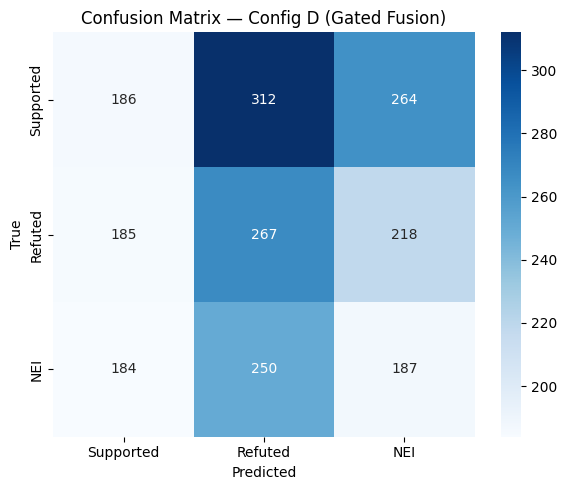

Confusion matrix saved → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_results/test_confusion_matrix.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_confusion_matrix(cm, class_names, output_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix — Config D (Gated Fusion)")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Confusion matrix saved → {output_path}")


if CONFIG["model"]["num_classes"] == 2:
    _class_names = ["Supported", "Refuted"]
else:
    _class_names = ["Supported", "Refuted", "NEI"]

_cm_path = CONFIG["paths"]["stage2_results_dir"] / "test_confusion_matrix.png"
plot_confusion_matrix(
    ablation_results["gated"]["confusion_matrix"],
    _class_names,
    _cm_path,
)

if mlflow_enabled:
    try:
        with mlflow.start_run(run_name="stage2_gated_eval"):
            mlflow.log_artifact(str(_cm_path))
        mlflow.end_run()
    except Exception:
        pass

## Step 12: JSON Results Export

Exports the full ablation summary and Config D detailed results to
`training/stage2_results/mm_vifactcheck_results.json` for thesis documentation (D-20, MMVF-07).


In [25]:
_results_json = {
    "metadata": {
        "run_completed_at": datetime.now().isoformat(),
        "stage1_checkpoint_path": str(stage1_checkpoint_path),
        "stage1_epoch": stage1_epoch,
        "num_classes": CONFIG["model"]["num_classes"],
        "mlflow_enabled": mlflow_enabled,
        "mlflow_experiment_name": CONFIG["mlflow"]["experiment_name"],
    },
    "ablation_summary": [
        {
            "config_label": cfg,
            "mode": cfg,
            "accuracy": ablation_results[cfg]["test_metrics"]["test_accuracy"],
            "macro_f1": ablation_results[cfg]["test_metrics"]["test_macro_f1"],
            "f1_per_class": {
                f"class{i}": ablation_results[cfg]["test_metrics"].get(
                    f"test_f1_class{i}", 0.0
                )
                for i in range(CONFIG["model"]["num_classes"])
            },
            "best_epoch": ablation_results[cfg]["best_epoch"],
        }
        for cfg in CONFIG["training"]["ablation_configs"]
    ],
    "best_config": {
        "mode": "gated",
        "config_label": "gated",
        "classification_report": ablation_results["gated"]["classification_report"],
        "confusion_matrix": ablation_results["gated"]["confusion_matrix"],
        "hyperparameters": {
            "lr": CONFIG["training"]["lr"],
            "weight_decay": CONFIG["training"]["weight_decay"],
            "batch_size": CONFIG["training"]["batch_size"],
            "label_smoothing": CONFIG["training"]["label_smoothing"],
            "fusion_hidden_dim": CONFIG["model"]["fusion_hidden_dim"],
            "dropout": CONFIG["model"]["dropout"],
        },
        "best_epoch": ablation_results["gated"]["best_epoch"],
        "val_macro_f1": ablation_results["gated"]["val_metrics"].get(
            "val_macro_f1", None
        ),
        "stage1_checkpoint_path": str(stage1_checkpoint_path),
        "stage1_epoch": stage1_epoch,
    },
}

_json_path = CONFIG["paths"]["stage2_results_dir"] / "mm_vifactcheck_results.json"
with open(_json_path, "w", encoding="utf-8") as f:
    json.dump(_results_json, f, indent=2, ensure_ascii=False)

print(f"Results JSON saved → {_json_path}")

Results JSON saved → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_results/mm_vifactcheck_results.json


## Step 13: Summary

Phase 4 complete. All ablation configs trained, evaluated, and results persisted.


In [26]:
print("=" * 60)
print("MM-ViFactCheck Stage 2 — Complete")
print("=" * 60)
print(f"Best config: gated")
print(
    f"  val_macro_f1 : {ablation_results['gated']['val_metrics'].get('val_macro_f1', '?'):.4f}"
)
print(
    f"  test_acc     : {ablation_results['gated']['test_metrics']['test_accuracy']:.4f}"
)
print(
    f"  test_macro_f1: {ablation_results['gated']['test_metrics']['test_macro_f1']:.4f}"
)
print()
print(f"Ablation CSV: {CONFIG['paths']['stage2_results_dir'] / 'ablation_table.csv'}")
print(
    f"Confusion matrix PNG: {CONFIG['paths']['stage2_results_dir'] / 'test_confusion_matrix.png'}"
)
print(
    f"Results JSON: {CONFIG['paths']['stage2_results_dir'] / 'mm_vifactcheck_results.json'}"
)
print()
print(f"Phase 5 (if applicable): /gsd-plan-phase 5")

MM-ViFactCheck Stage 2 — Complete
Best config: gated
  val_macro_f1 : 0.3716
  test_acc     : 0.3117
  test_macro_f1: 0.3095

Ablation CSV: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_results/ablation_table.csv
Confusion matrix PNG: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_results/test_confusion_matrix.png
Results JSON: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage2_results/mm_vifactcheck_results.json

Phase 5 (if applicable): /gsd-plan-phase 5
